### Library Imports and Styling

This cell initializes the environment. It imports **Pandas** for data manipulation, **Matplotlib** and **Seaborn** for data visualization, and the `os` module. Additionally, it sets the aesthetic style of the plots to "whitegrid" for better readability.

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

### Data Loading

This block loads the dataset from the relative path `../data/superstore.csv`. It specifies `latin1` encoding to handle special characters commonly found in retail datasets. The `df.head()` command displays the first five rows to verify the successful load.

In [96]:
df = pd.read_csv("../data/superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Dataset Shape

This identifies the dimensions of the dataset. It returns a tuple representing the total number of rows (observations) and columns (variables).

In [97]:
df.shape

(9994, 21)

### Data Information

This command provides a summary of the DataFrame, including the column names, non-null counts, and memory usage. It is essential for identifying data types (e.g., seeing that the date columns are currently stored as strings).

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

### Descriptive Statistics

This generates descriptive statistics for quantitative columns, such as `Sales`, `Quantity`, `Discount`, and `Profit`. It shows the mean, standard deviation, minimum/maximum values, and quartiles.

In [99]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Null Value Detection

This block performs a data quality check by counting the number of missing (NaN) values in each column. This is a critical step in the data cleaning process.

In [100]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Duplicate Removal

This ensures data integrity by removing any identical rows from the dataset. It prevents inflation of sales figures caused by duplicate records.

In [101]:
df = df.drop_duplicates()
print("Duplicates Removed")

Duplicates Removed


### Date Type Conversion

The `Order Date` column is converted from a generic string object to a proper **datetime** object. This enables time-series operations, such as extracting the month or year.

In [102]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

### Feature Engineering (Time Components)

This block extracts the **Year**, **Month number**, and **Month name** from the `Order Date` and creates three new columns. This facilitates grouping and analyzing sales performance seasonally or annually.

In [103]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


### Yearly Sales Aggregation

This calculates the total sales for each unique year in the dataset. It uses the `groupby` function to crunch the numbers at an annual scale.

In [104]:
sales_trend = df.groupby("Year")["Sales"].sum()

sales_trend

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

### Yearly Sales Visualization

This generates a line plot showcasing how sales have trended over the years. The `marker="o"` adds distinct points for each year to clarify the growth or decline in revenue.

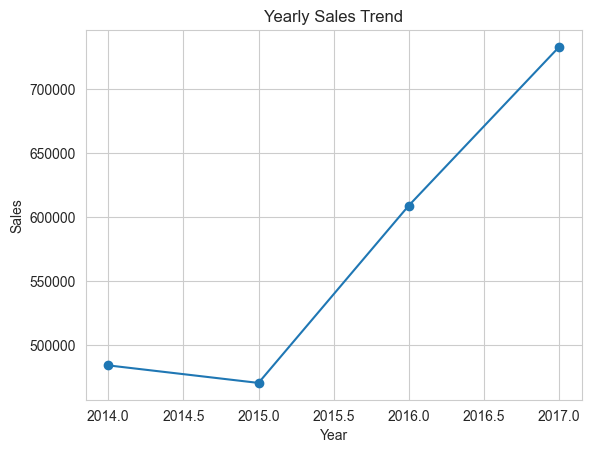

In [105]:
plt.figure()

sales_trend.plot(marker="o")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()


plt.close()

### Product Sub-Category Analysis

This identifies which sub-categories (like Phones or Chairs) generate the most revenue. It groups the data, sums the sales, and sorts them in descending order to isolate the top 10 contributors.

In [106]:
top_products = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

top_products.head(10)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

### Top Products Visualization

This cell creates a bar chart for the top 10 sub-categories. It provides a visual comparison of revenue performance across different product lines.

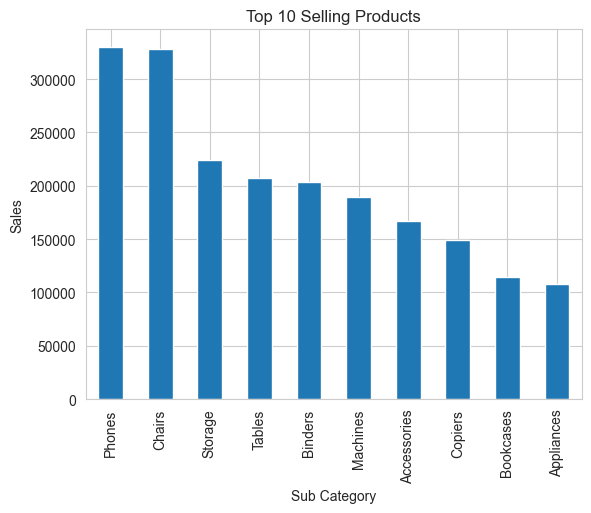

In [107]:
plt.figure()

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Sub Category")
plt.ylabel("Sales")

plt.show()


plt.close()

### Regional Sales Aggregation

This calculates the total sales for each geographical region (Central, East, South, West). It helps determine which markets are the most lucrative.

In [108]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

### Regional Sales Visualization

This block visualizes regional performance using a bar chart, allowing for immediate identification of the strongest and weakest performing regions.

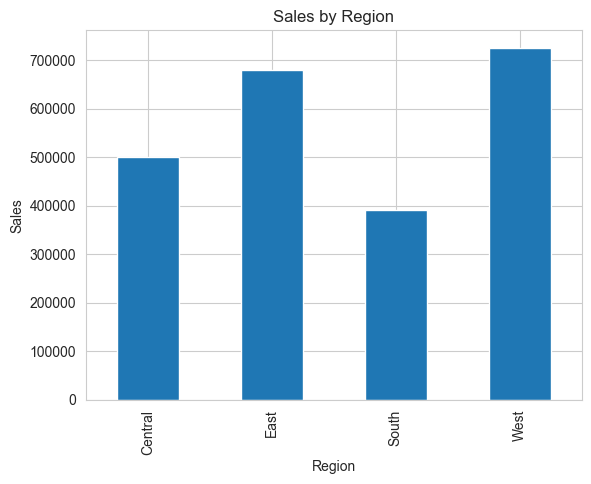

In [109]:
plt.figure()

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()


plt.close()

### Data Correlation Analysis

This uses a scatter plot to examine the relationship between `Sales` and `Profit`. It helps in identifying if higher sales always lead to higher profits or if there are cases of high-sales but low-profit transactions.

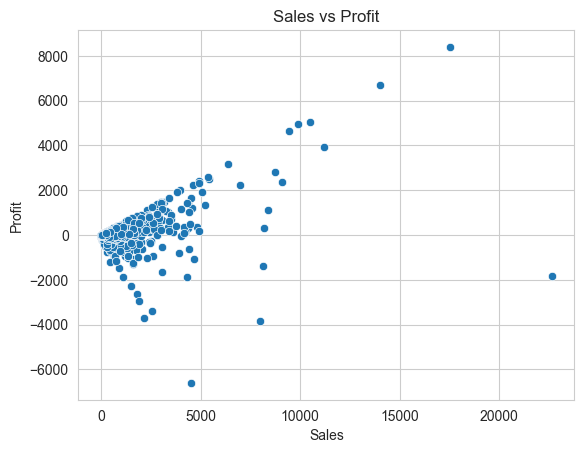

In [110]:
plt.figure()

sns.scatterplot(x="Sales", y="Profit", data=df)

plt.title("Sales vs Profit")

plt.show()


plt.close()

### Category Sales Distribution Visualization

This generates a pie chart showing the percentage contribution of each category to the total sales. The `autopct` parameter displays the percentage values directly on the chart.

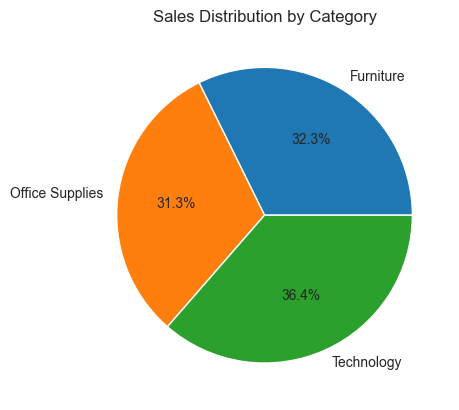

In [111]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure()

category_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Sales Distribution by Category")
plt.ylabel("")

plt.show()


plt.close()

### Exporting Cleaned Data

The final block saves the fully cleaned and transformed DataFrame to a new CSV file named `cleaned_superstore.csv` in the `data` directory. Setting `index=False` prevents Pandas from writing the row indices as an extra column.

In [112]:
output_path = "../data/cleaned_superstore.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset")

Cleaned dataset
